In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [1]:
pip install numpy pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
data = pd.read_excel(r"C:\Users\sanja\Downloads\hospitaleeee.xlsx" )

In [4]:
print("Raw shape:", data.shape)

Raw shape: (7347, 10)


In [5]:
data.head()

,Primary Diagnosis Code,Primary Diagnosis Code Description,All Attendances,Attended first appointment,Attended first tele consultation,Attended subsequent appointment,Attended subsequent tele consultation,Attended but first / subsequent / tele unknown,Percentage of all attendances,Follow-up attendances for each first attendance
0,All,Total Activity,113225153,32380319,5036934,61066503,14725395,16002,1.000,2
1,Unknown categories,Unknown and unspecified causes of morbidity,104324890,30115298,4745758,56032738,13415117,15979,0.921,2
2,A009,Typhoid fever,68,21,3,44,0,0,0.000,1.8
3,A010,Paratyphoid fever A,3,3,0,0,0,0,0.000,0
4,A011,"Paratyphoid fever, unspecified",1,1,0,0,0,0,0.000,0


In [6]:
data.columns = [c.strip().replace("\xa0", "") for c in data.columns]

In [7]:
data = data.rename(columns={
    "All Attendances": "all_attendances",
    "Attended first appointment": "first_appointment",
    "Attended first tele consultation": "first_tele",
    "Attended subsequent appointment": "subsequent_appointment",
    "Attended subsequent tele consultation": "subsequent_tele",
    "Attended but first / subsequent / tele unknown": "unknown_attendance_type",
    "Percentage of all attendances": "pct_of_all_attendances",
    "Follow-up attendances for each first attendance": "followup_ratio",
})
 
print(data.columns.tolist())

['Primary Diagnosis Code', 'Primary Diagnosis Code Description', 'all_attendances', 'first_appointment', 'first_tele', 'subsequent_appointment', 'subsequent_tele', 'unknown_attendance_type', 'pct_of_all_attendances', 'followup_ratio']


In [8]:
numeric_cols = [
    "all_attendances", "first_appointment", "first_tele",
    "subsequent_appointment", "subsequent_tele",
    "unknown_attendance_type", "pct_of_all_attendances", "followup_ratio",
]

In [9]:
dq_report = {}
for col in numeric_cols:
    cleaned = (
        data[col].astype(str).str.replace(",", "", regex=False).str.strip()
    )
    coerced = pd.to_numeric(cleaned, errors="coerce")
    dq_report[col] = {
        "non_numeric_before_fill": coerced.isna().sum(),
        "pct_non_numeric": round(coerced.isna().mean() * 100, 2),
    }
    data[col] = coerced  # NaN kept for now, NOT filled yet
 

In [10]:
dq_df = pd.DataFrame(dq_report).T
print("\n===== DATA QUALITY REPORT (before fillna) =====")
print(dq_df)


===== DATA QUALITY REPORT (before fillna) =====
                         non_numeric_before_fill  pct_non_numeric
all_attendances                             10.0             0.14
first_appointment                            9.0             0.12
first_tele                                   2.0             0.03
subsequent_appointment                       7.0             0.10
subsequent_tele                              3.0             0.04
unknown_attendance_type                      0.0             0.00
pct_of_all_attendances                       0.0             0.00
followup_ratio                               7.0             0.10


In [11]:
data[numeric_cols] = data[numeric_cols].fillna(0)
 

In [12]:
AGGREGATE_LABELS = ["Total Activity", "Unknown and unspecified causes of morbidity"]

In [13]:
aggregates = data[data["Primary Diagnosis Code Description"].isin(AGGREGATE_LABELS)].copy()
data = data[~data["Primary Diagnosis Code Description"].isin(AGGREGATE_LABELS)].copy()
data = data.reset_index(drop=True)
 
print(f"\nRemoved {len(aggregates)} aggregate rows. Clean diagnosis-level rows: {len(data)}")


Removed 2 aggregate rows. Clean diagnosis-level rows: 7345


In [14]:
total_check = data["all_attendances"].sum()
official_total = aggregates.loc[
    aggregates["Primary Diagnosis Code Description"] == "Total Activity", "all_attendances"
].values[0]
print(f"Sum of clean diagnosis rows: {total_check:,.0f} vs official total: {official_total:,.0f} "
      f"({total_check/official_total:.1%} captured)")

Sum of clean diagnosis rows: 8,900,245 vs official total: 113,225,153 (7.9% captured)


In [15]:
data["total_tele"] = data["first_tele"] + data["subsequent_tele"]
data["total_in_person"] = data["first_appointment"] + data["subsequent_appointment"]
data["tele_adoption_rate"] = np.where(
    data["all_attendances"] > 0,
    data["total_tele"] / data["all_attendances"],0,)



In [16]:
data["unknown_rate"] = np.where(
    data["all_attendances"] > 0,
    data["unknown_attendance_type"] / data["all_attendances"],0,)
 

In [17]:
pareto = (
    data.groupby("Primary Diagnosis Code Description")["all_attendances"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
pareto["cumulative_pct"] = pareto["all_attendances"].cumsum() / pareto["all_attendances"].sum() * 100
n_for_80 = (pareto["cumulative_pct"] <= 80).sum()
 
print(f"\n===== PARETO =====")
print(f"{n_for_80} of {len(pareto)} diagnoses ({n_for_80/len(pareto):.1%} of all diagnoses) "
      f"account for 80% of outpatient attendances")
 
top20_volume = pareto.head(20)
 



===== PARETO =====
568 of 7129 diagnoses (8.0% of all diagnoses) account for 80% of outpatient attendances


In [18]:
VOLUME_FLOOR = data["all_attendances"].quantile(0.75)
 
high_volume = data[data["all_attendances"] >= VOLUME_FLOOR]
top_followup_burden = (
    high_volume[["Primary Diagnosis Code Description", "all_attendances", "followup_ratio"]]
    .sort_values("followup_ratio", ascending=False)
    .head(20)
)
print("\n===== TOP FOLLOW-UP BURDEN (high-volume diagnoses only) =====")
print(top_followup_burden)
 




===== TOP FOLLOW-UP BURDEN (high-volume diagnoses only) =====
                     Primary Diagnosis Code Description  all_attendances  \
7002                            Artificial insemination           1098.0   
7155      Person consulting on behalf of another person           3545.0   
6992                         Prophylactic immunotherapy            544.0   
7110                                       Kidney donor           1596.0   
442   Malignant neoplasm: Tonsillar pillar (anterior...            523.0   
601   Malignant neoplasm: Specified parts of peritoneum            633.0   
449   Malignant neoplasm: Overlapping lesion of orop...            561.0   
2329  Retained (old) intraocular foreign body, nonma...            737.0   
1077    Refractory anaemia with excess of blasts [RAEB]            946.0   
7080  Fitting and adjustment of other specified devices           2679.0   
662        Malignant neoplasm: Anterior wall of bladder            517.0   
1081                    O

In [19]:
tele_gap = (
    high_volume[["Primary Diagnosis Code Description", "all_attendances",
                 "total_tele", "tele_adoption_rate"]]
    .sort_values("tele_adoption_rate", ascending=True)
    .head(20)
)
print("\n===== TELEMEDICINE ADOPTION GAP (high volume, low tele use) =====")
print(tele_gap)
 


===== TELEMEDICINE ADOPTION GAP (high volume, low tele use) =====
                     Primary Diagnosis Code Description  all_attendances  \
443    Malignant neoplasm: Overlapping lesion of tonsil           1082.0   
6905  Radiological examination, not elsewhere classi...          15705.0   
2267                                  Diabetic cataract          39909.0   
2254                              Other senile cataract         127368.0   
2260                                     After-cataract         171334.0   
7082  Follow-up care involving removal of fracture p...           1051.0   
2251                          Senile incipient cataract          11380.0   
3067                          Malocclusion, unspecified          20136.0   
3065              Anomalies of dental arch relationship          42382.0   
4428                            Mild cervical dysplasia           3915.0   
4507                                Abdominal pregnancy            672.0   
2252                 

In [20]:
governance_flag = (
    data[data["unknown_attendance_type"] > 0]
    [["Primary Diagnosis Code Description", "all_attendances", "unknown_attendance_type", "unknown_rate"]]
    .sort_values("unknown_attendance_type", ascending=False)
    .head(15)
)
total_unknown = data["unknown_attendance_type"].sum()
print(f"\n===== DATA GOVERNANCE: unclassified attendance type =====")
print(f"Total unclassified attendances across dataset: {total_unknown:,.0f} "
      f"({total_unknown/data['all_attendances'].sum():.2%} of all attendances)")
print(governance_flag)
 



===== DATA GOVERNANCE: unclassified attendance type =====
Total unclassified attendances across dataset: 23 (0.00% of all attendances)
                     Primary Diagnosis Code Description  all_attendances  \
1508                       Disorders of iron metabolism           6210.0   
2297          Degeneration of macula and posterior pole         156386.0   
5718                                 Other chronic pain          23117.0   
3746                  Pauciarticular juvenile arthritis            289.0   
3748                    Juvenile arthritis, unspecified           8193.0   
689                      Malignant neoplasm: Brain stem            322.0   
964                      Melanocytic naevi, unspecified          10650.0   
2607                  Other hypertrophic cardiomyopathy           7578.0   
1390            Short stature, not elsewhere classified           3410.0   
1341                                    Hypopituitarism           4209.0   
3711  Disorder of skin and s

In [21]:
scorecard = high_volume.copy()
scorecard["volume_rank"] = scorecard["all_attendances"].rank(ascending=False, pct=True)
scorecard["followup_rank"] = scorecard["followup_ratio"].rank(ascending=False, pct=True)
scorecard["tele_gap_rank"] = scorecard["tele_adoption_rate"].rank(ascending=True, pct=True)

In [22]:
scorecard["priority_score"] = (
    0.4 * scorecard["volume_rank"]
    + 0.3 * scorecard["followup_rank"]
    + 0.3 * scorecard["tele_gap_rank"]
)
 
priority_table = (
    scorecard[["Primary Diagnosis Code Description", "all_attendances",
               "followup_ratio", "tele_adoption_rate", "priority_score"]]
    .sort_values("priority_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
print("\n===== TOP 20 PRIORITY DIAGNOSES (volume + follow-up burden + low tele uptake) =====")
print(priority_table)



===== TOP 20 PRIORITY DIAGNOSES (volume + follow-up burden + low tele uptake) =====
                   Primary Diagnosis Code Description  all_attendances  \
0          Special screening examination, unspecified            437.0   
1                                             Melaena            541.0   
2   Abnormal findings on diagnostic imaging of liv...            544.0   
3                                           Heartburn            439.0   
4   Dislocation, sprain and strain of unspecified ...            424.0   
5   Supervision of pregnancy with history of abort...            456.0   
6                                     Amaurosis fugax            482.0   
7           Other specified diseases of biliary tract            498.0   
8                               Alcoholic fatty liver            577.0   
9                 Benign neoplasm: Colon, unspecified            492.0   
10  Family history of malignant neoplasm, unspecified            787.0   
11                         

In [23]:
top5 = priority_table.head(5)["Primary Diagnosis Code Description"]
top5_data = data[data["Primary Diagnosis Code Description"].isin(top5)]
slots_freed = (top5_data["subsequent_appointment"] * 0.10).sum()
print(f"\n===== ILLUSTRATIVE IMPACT =====")
print(f"Shifting 10% of subsequent in-person appointments to tele for the top-5 "
      f"priority diagnoses would free an estimated {slots_freed:,.0f} in-person clinic slots.")
 


===== ILLUSTRATIVE IMPACT =====
Shifting 10% of subsequent in-person appointments to tele for the top-5 priority diagnoses would free an estimated 50 in-person clinic slots.


In [24]:
export_cols = [
    "Primary Diagnosis Code", "Primary Diagnosis Code Description",
    "all_attendances", "first_appointment", "first_tele",
    "subsequent_appointment", "subsequent_tele", "unknown_attendance_type",
    "total_tele", "total_in_person", "tele_adoption_rate",
    "followup_ratio", "unknown_rate",
]


In [29]:
exporting = data[export_cols].copy()
exporting["priority_score"] = scorecard.set_index(scorecard.index)["priority_score"]
exporting["priority_score"] = exporting["priority_score"].fillna(0)
 
exporting.to_csv(
    r"C:\Users\sanja\Desktop\nhs_outpatient_dataaa.csv",
    index=False
)

Exported successfully


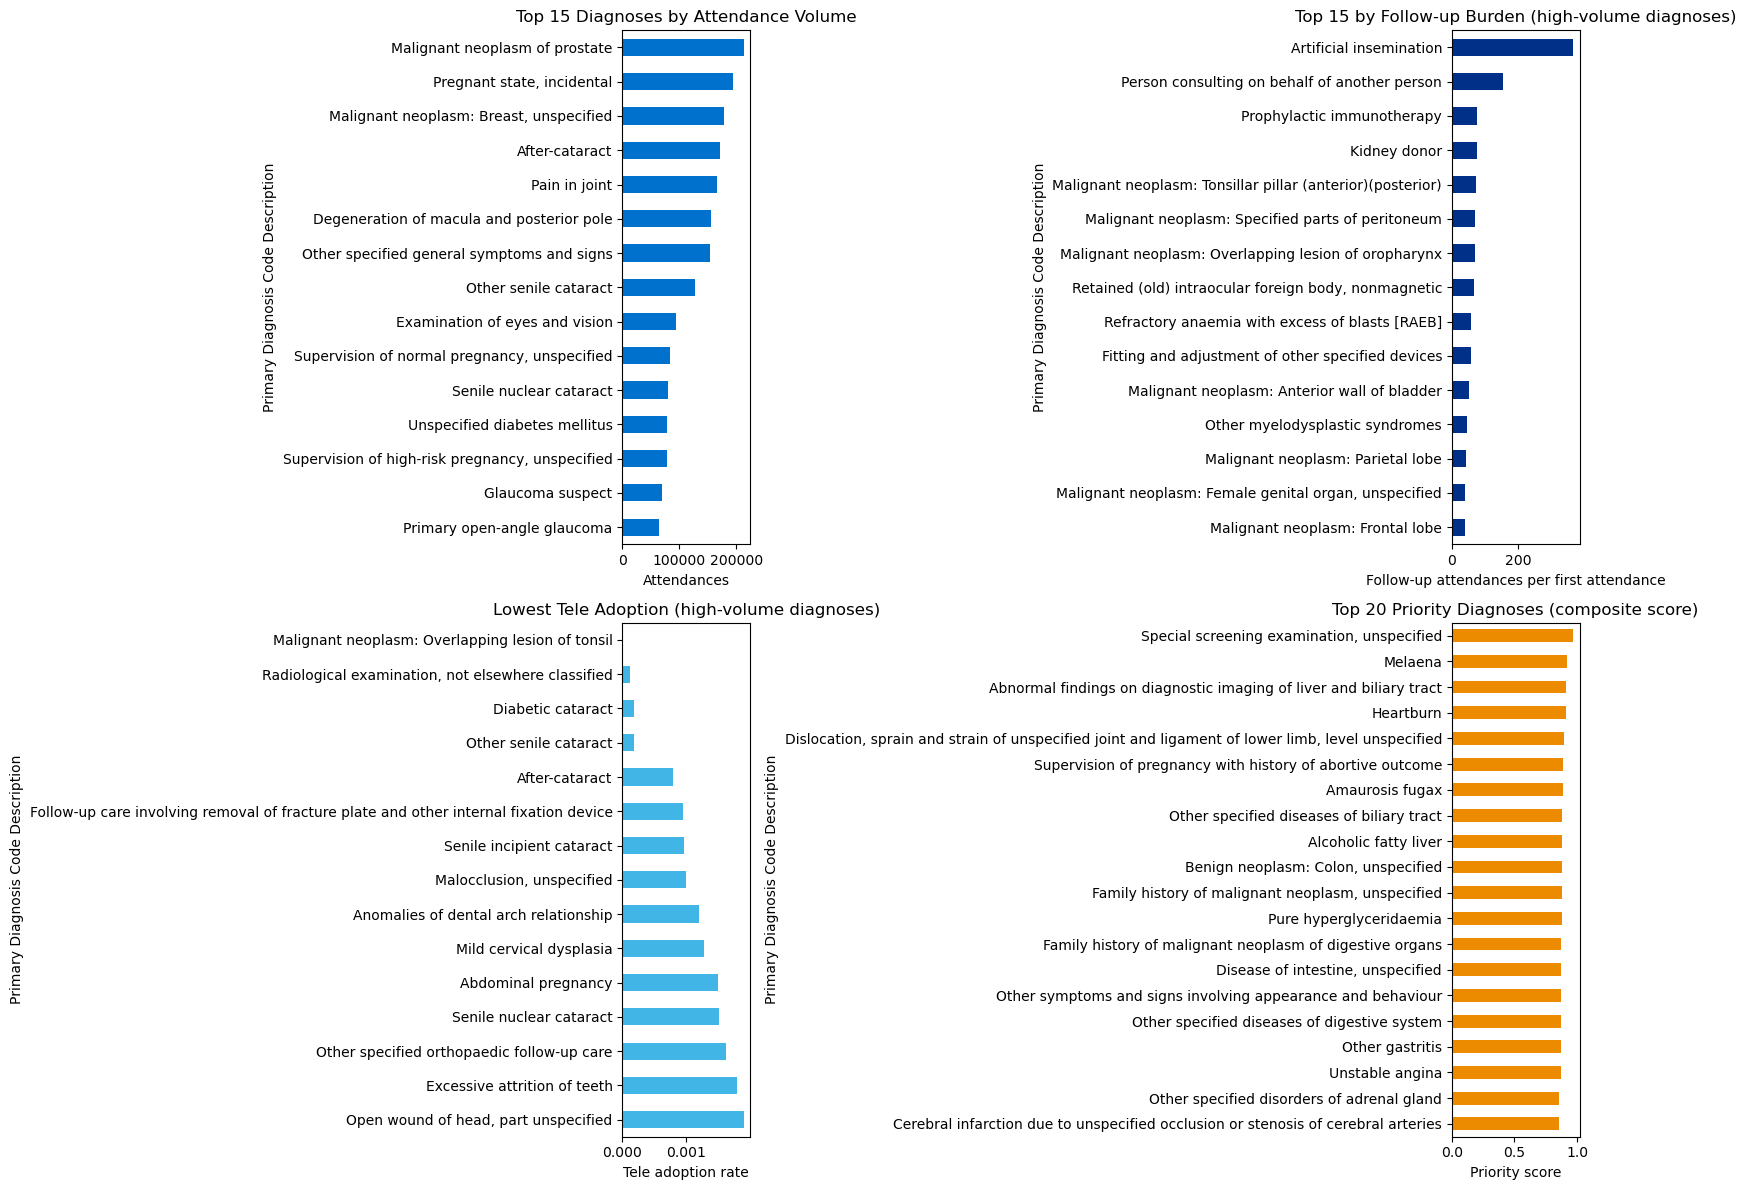


Done. Charts saved to nhs_outpatient_summary_charts.png


In [28]:
#dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
top20_volume.set_index("Primary Diagnosis Code Description")["all_attendances"] \
    .sort_values().tail(15).plot(kind="barh", ax=axes[0, 0], color="#0072CE")
axes[0, 0].set_title("Top 15 Diagnoses by Attendance Volume")
axes[0, 0].set_xlabel("Attendances")
 
top_followup_burden.set_index("Primary Diagnosis Code Description")["followup_ratio"] \
    .sort_values().tail(15).plot(kind="barh", ax=axes[0, 1], color="#003087")
axes[0, 1].set_title("Top 15 by Follow-up Burden (high-volume diagnoses)")
axes[0, 1].set_xlabel("Follow-up attendances per first attendance")
 
tele_gap.set_index("Primary Diagnosis Code Description")["tele_adoption_rate"] \
    .sort_values(ascending=False).tail(15).plot(kind="barh", ax=axes[1, 0], color="#41B6E6")
axes[1, 0].set_title("Lowest Tele Adoption (high-volume diagnoses)")
axes[1, 0].set_xlabel("Tele adoption rate")
 
priority_table.set_index("Primary Diagnosis Code Description")["priority_score"] \
    .sort_values().plot(kind="barh", ax=axes[1, 1], color="#ED8B00")
axes[1, 1].set_title("Top 20 Priority Diagnoses (composite score)")
axes[1, 1].set_xlabel("Priority score")
 
plt.tight_layout()
plt.savefig("nhs_outpatient_summary_charts.png", dpi=150)
plt.show()
 
print("\nDone. Charts saved to nhs_outpatient_summary_charts.png")